# EZyRB Tutorial 4
## Build a Multi Reduced Order Model (MultiROM)

In this tutorial, we will show how to aggregate the predictions of different ROMs following the method presented in the [paper by Ivagnes et al.](https://link.springer.com/content/pdf/10.1007/s00707-024-04007-9.pdf)

Let's call $\boldsymbol{\eta}=(\boldsymbol{x}, \boldsymbol{\mu})$ the problem's features, namely the space coordinates and the parameters.

The idea is to build and combine a set of ROMs $\{\mathcal{M}_1, \mathcal{M}_2, \dots, \mathcal{M}_{N}\}$, to approximate a specific high-fidelity field, for instance the parametrized velocity $\boldsymbol{u}(\boldsymbol{\eta})$. The individual ROMs differ in the reduction approach and/or in the approximation technique. The **MultiROM prediction** will then be a convex combination of the predictions of the pre-trained individual ROMs. If the $i$-th ROM prediction is $\tilde{\boldsymbol{u}}^{(i)}(\boldsymbol{\eta})$, then the MultiROM prediction will be:
$$\tilde{\boldsymbol{u}}(\boldsymbol{\eta}) = \sum_{i=1}^{N} w^{(i)}(\boldsymbol{\eta}) \tilde{\boldsymbol{u}}^{(i)}(\boldsymbol{\eta}) ,$$
where the weights associated with each ROM in the convex combination are space- and parameter-dependent. In this way, the **MultiROM** should effectively and automatically identify the ROM with the optimal performance across various regions of the spatial and parameter domains.

To build the model, we have to design a method to compute the weights, also in unseen settings.
We here consider a dataset from the library **Smithers** (`NavierStokesDataset`), and we divide it into three subsets:
- the **training** dataset (composed of $M_{\text{train}}$ instances): used to train the individual ROMs;
- the **evaluation** dataset (composed of $M_{\text{evaluation}}$ instances): used to compute the optimal weights;
- the **test** dataset (composed of $M_{\text{test}}$ instances): used to test our methodology, where the weights are approximated with a regression technique.

Now the question is: *How to compute the weights?*
We here consider two different approaches:
- **XMA** (as in [de Zordo-Banliat et al.](https://www.sciencedirect.com/science/article/abs/pii/S0021999123007234)), where the weights are computed in the evaluation set, using the following expression:
  $$w^{(i)}(\boldsymbol{\eta})=\dfrac{g^{(i)}(\boldsymbol{\eta})}{\sum_{i=1}^N g^{(i)}(\boldsymbol{\eta})}, \, g^{(i)}(\boldsymbol{\eta})=\text{exp}\left( - \dfrac{1}{2} \dfrac{(\tilde{\boldsymbol{u}}^{(i)}(\boldsymbol{\eta}) - \boldsymbol{u}(\boldsymbol{\eta}))^2}{\sigma^2} \right),\, \text{for } \boldsymbol{\eta}=\boldsymbol{\eta}_{\text{evaluation}}.
  $$ In the test set, a regression approach (`KNN`) is used to approximate the weights at unseen $\boldsymbol{\eta}=\boldsymbol{\eta}_{\text{test}}$.   

- **ANN**: a neural network takes as input $\boldsymbol{\eta}$, and gives as output directly the weights $w^{(i)}, i=1, \dots, N,$ of the convex combination. It is trained to minimize the following loss:
$$\mathcal{L}=\frac{1}{M_{\textrm{test}}} \sum_{j=1}^{M_{\textrm{test}}}\left(\sum_{i=1}^N \left(w^{(i)}(\boldsymbol{\eta}_j) \tilde{\boldsymbol{u}}^{(i)}(\boldsymbol{\eta}_j)\right) - \boldsymbol{u}(\boldsymbol{\eta}_j) \right)^2$$

Let's begin the tutorial with some useful imports.

In [1]:
import numpy as np
import copy
%pip install -e ../
from ezyrb import Database
from ezyrb import POD, AE
from ezyrb import RBF, GPR, ANN, KNeighborsRegressor
from ezyrb import ReducedOrderModel as ROM
from ezyrb import MultiReducedOrderModel as MultiROM
from ezyrb.plugin import Aggregation, DatabaseSplitter
from smithers.dataset import NavierStokesDataset
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from matplotlib.colors import LogNorm

Obtaining file:///Users/aivagnes/Desktop/Work/Packages/EZyRB
  Preparing metadata (setup.py) ... done
  Attempting uninstall: ezyrb
    Found existing installation: ezyrb 1.3.0
    Uninstalling ezyrb-1.3.0:
      Successfully uninstalled ezyrb-1.3.0
  Running setup.py develop for ezyrb

[notice] A new release of pip is available: 24.1.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
def plot_fields(fields, triangles, labels=None, shared_cmap=True, log_cmap=False, cmap="viridis"):
    n = len(fields)
    fig, ax = plt.subplots(ncols=n, nrows=1, figsize=(3.5*n, 4))

    if n == 1:
        ax = [ax]

    plots = []

    # normalization
    norm = None
    if log_cmap:
        if shared_cmap:
            vmin = min(f.min() for f in fields if f.min() > 0)
            vmax = max(f.max() for f in fields)
            norm = LogNorm(vmin=vmin, vmax=vmax)

    if shared_cmap:
        # global limits
        if not log_cmap:
            vmin = min(f.min() for f in fields)
            vmax = max(f.max() for f in fields)
        for i, field in enumerate(fields):
            im = ax[i].tricontourf(
                triangles, field, 
                vmin=None if log_cmap else vmin, 
                vmax=None if log_cmap else vmax, 
                norm=norm, cmap=cmap
            )
            plots.append(im)
            if labels is not None:
                ax[i].set_title(labels[i])
        # unica colorbar
        fig.colorbar(plots[-1], ax=ax, orientation="vertical", fraction=0.046, pad=0.04)

    else:
        for i, field in enumerate(fields):
            if log_cmap:
                vmin = field[field > 0].min()
                vmax = field.max()
                norm = LogNorm(vmin=vmin, vmax=vmax)
            im = ax[i].tricontourf(triangles, field, norm=norm, cmap=cmap)
            plots.append(im)
            if labels is not None:
                ax[i].set_title(labels[i])
            fig.colorbar(im, ax=ax[i], orientation="vertical", fraction=0.046, pad=0.04)

    plt.show()

In [3]:
class ANN_weights(ANN):
    def __init__(self, mrom, layers, function, stop_training, loss=None,
                 optimizer=torch.optim.Adam, lr=0.001, l2_regularization=0,
                 frequency_print=500, last_identity=True):
        super().__init__(layers, function, stop_training, loss=None,
                 optimizer=torch.optim.Adam, lr=0.001, l2_regularization=0,
                 frequency_print=10, last_identity=True)

        # import useful data from multirom and roms predictions
        self.mrom = mrom
        self.params = list(self.mrom.roms.values())[0].validation_full_database.parameters_matrix
        
        self.frequency_print = frequency_print
        self.lr = lr
        self.l2_regularization = l2_regularization

        # import ROMs and validation predictions of all ROMs
        self.rom_validation_predictions = {}
        for rom in self.mrom.roms:
            rom_pred = self.mrom.roms[rom]
            rom_pred = rom_pred.predict(self.params)
            rom_pred = rom_pred.reshape(rom_pred.shape[0]*rom_pred.shape[1], 1)
            self.rom_validation_predictions[rom] = self._convert_numpy_to_torch(rom_pred)
            
        # Device configuration
        self.device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
        print(f"Using device: 💻 {self.device}")
        
    def _build_model_(self, points):
        layers = self.layers.copy()
        layers.insert(0, points.shape[1])
        layers.append(len(self.mrom.roms))
        self.model = self._list_to_sequential(layers, self.function)
        
        # Move the model to the device
        self.model.to(self.device)

    def fit(self, points, values): # points=(x, mu) and values=(snapshots)
        self._build_model_(points)
        optimizer = self.optimizer(
            self.model.parameters(),
            lr=self.lr, weight_decay=self.l2_regularization)
        
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.9, patience=1000)

        points = self._convert_numpy_to_torch(points)
        values = self._convert_numpy_to_torch(values)
        
        # Move everything to the device
        points = points.to(self.device)
        values = values.to(self.device)
        self.rom_validation_predictions = {rom: pred.to(self.device) for rom, pred in self.rom_validation_predictions.items()}

        # train the neural network
        n_epoch = 1
        flag = True
        while flag:
            # compute output of ANN
            y_pred = self.model(points)

            # compute aggregated solution from output weights of ANN
            aggr_pred = torch.zeros(values.shape, device=self.device)
            for i, rom in enumerate(self.mrom.roms):
                weight = y_pred.clone()[..., i].unsqueeze(-1)
                aggr_pred += weight*self.rom_validation_predictions[rom]

            # difference between aggregated solution and exact solution
            loss = self.loss(aggr_pred, values)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            scalar_loss = loss.item()
            self.loss_trend.append(scalar_loss)
            
            scheduler.step(scalar_loss)

            for criteria in self.stop_training:
                if isinstance(criteria, int):  # stop criteria is an integer
                    if n_epoch == criteria:
                        flag = False
                elif isinstance(criteria, float):  # stop criteria is float
                    if scalar_loss < criteria:
                        flag = False

            if (flag is False or
                    n_epoch == 1 or n_epoch % self.frequency_print == 0):
                print(f'[epoch {n_epoch:6d}]\t{scalar_loss:e}')

            n_epoch += 1

        return optimizer

    def predict(self, x):
        
        # Move the model to the device
        x = self._convert_numpy_to_torch(np.array(x))
        x = x.to(self.device)
        y_new = self.model(x)
        ynew = y_new.cpu().detach().numpy()
        return ynew
    
    def plot_loss(self):
        '''
        Plot the loss function for visualization.
        '''
        fig = plt.figure(figsize=(10, 6))
        plt.plot(self.loss_trend, marker='o', color='blue', markersize=3)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Train Loss', fontsize=12)
        plt.yscale('log')
        plt.title('Train Loss vs Epochs', fontsize=14)
        plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
        
        plt.show()

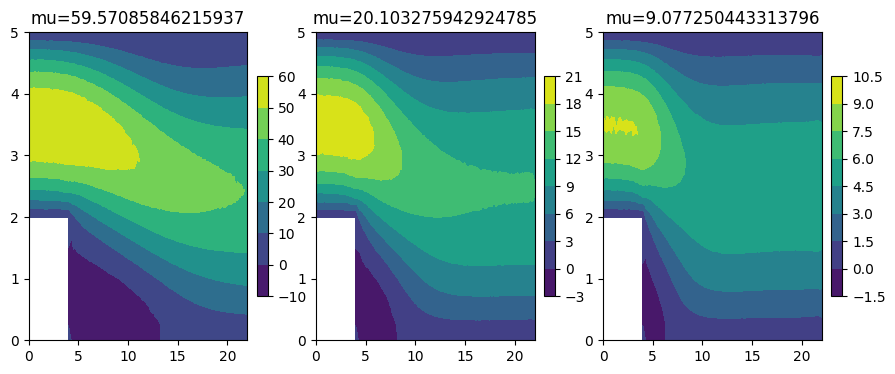

In [4]:
data = NavierStokesDataset()
field = 'vx'
coords = data.pts_coordinates.T
params = data.params
snaps = data.snapshots[field]
indices_plot = [0, 100, 200]
plot_fields([snaps[i, :] for i in indices_plot],
            data.triang, labels=["mu="+str(float(params[i])) for i in indices_plot],
            shared_cmap=False
             )

Then, we can create the database and initialize the reduction and approximation approaches. Here, we decide to consider POD-RBF and AE-RBF as individual ROMs. 

In [5]:
# Create the database
db_all = Database(data.params, data.snapshots[field], coords)

# Define some reduction and approximation methods to test
rank = 2
reduction_methods = {
    'POD': POD('svd', rank=rank),
    'AE': AE([100, 10, rank], [rank, 10, 100], nn.Softplus(), nn.Softplus(), 15000, lr=3e-4, frequency_print=500)
}
approximation_methods = {
    'RBF': RBF()
}

We now define the ROMs (store into a simple dictionary). Note that we use the `DatabaseSplitter` plugin to split our database into train, validation, test, and predict sets. Here we will only use the train, validation, and predict sets.

In [6]:
# Define a dictionary to store the ROMs

roms_dict = {}
db_splitter_plugin = DatabaseSplitter(train=0.6, validation=0.3, test=0.,
                                            predict=0.1, seed=42)
# Train a ROM for each combination of reduction and approximation
for redname, redclass in reduction_methods.items():
    for approxname, approxclass in approximation_methods.items():
        rom = ROM(copy.deepcopy(db_all),
                  copy.deepcopy(redclass),
                  copy.deepcopy(approxclass),
                  plugins=[db_splitter_plugin])
        roms_dict[f'{redname}_{approxname}'] = rom

Then, the definition of the `MultiROM` follows. Tirst, we then fit the MultiROM, namely we train the individual ROMs separately.

In [7]:
# Build a simple multiROM without aggregation and save it
multirom_noagg = MultiROM(roms_dict)
# Fit the multiROM (this step may last some time)
multirom_noagg.fit()

[epoch      1]	5.794518e+02
[epoch    500]	8.337958e-02
[epoch   1000]	2.426978e-02
[epoch   1500]	6.579667e-03
[epoch   2000]	3.966658e-03
[epoch   2500]	2.574558e-03
[epoch   3000]	4.067173e-03
[epoch   3500]	1.231169e-03
[epoch   4000]	9.459034e-04
[epoch   4500]	7.869854e-04
[epoch   5000]	5.980570e-04
[epoch   5500]	4.692916e-04
[epoch   6000]	5.433694e-04
[epoch   6500]	1.326763e-03
[epoch   7000]	2.102341e-04
[epoch   7500]	1.714763e-04
[epoch   8000]	1.349217e-04
[epoch   8500]	1.155644e-04
[epoch   9000]	1.251577e-04
[epoch   9500]	9.007328e-05
[epoch  10000]	9.661928e-05


In [8]:
# Get the dictionary of ROMs
roms_dict = multirom_noagg.roms

# Extract one ROM from the dictionary, and read the validation and test databases
rom_one = list(multirom_noagg.roms.values())[0]
db_validation = rom_one.validation_full_database
db_test = rom_one.predict_full_database

Test parameter for plotting:  2.409551792506808


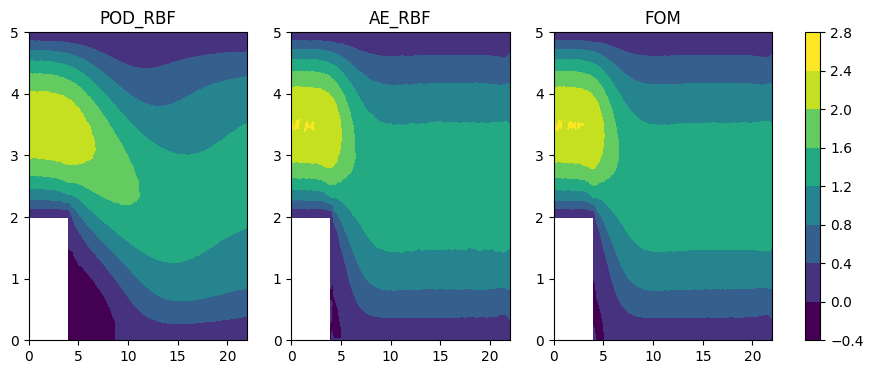

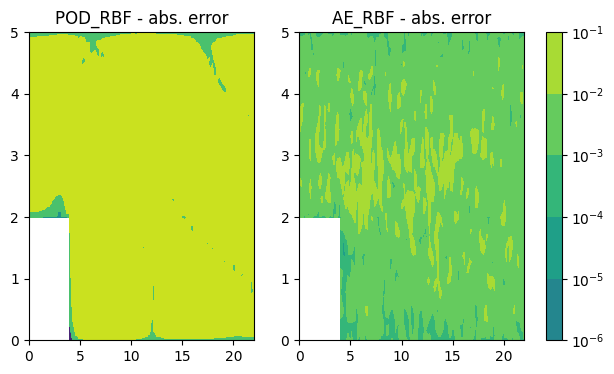

Test parameter for plotting:  78.61875700992475


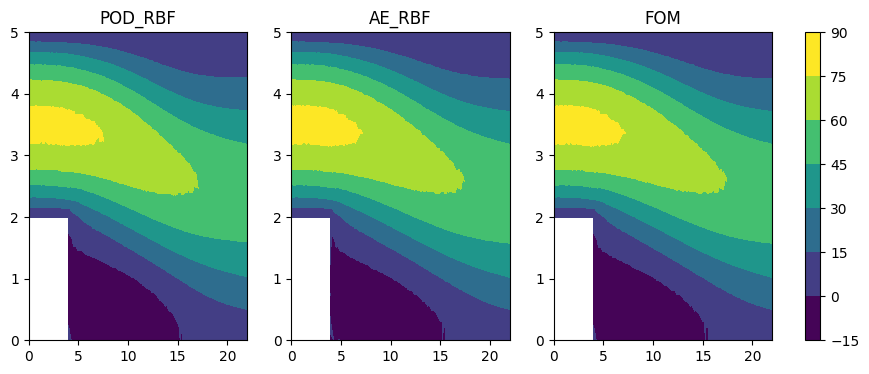

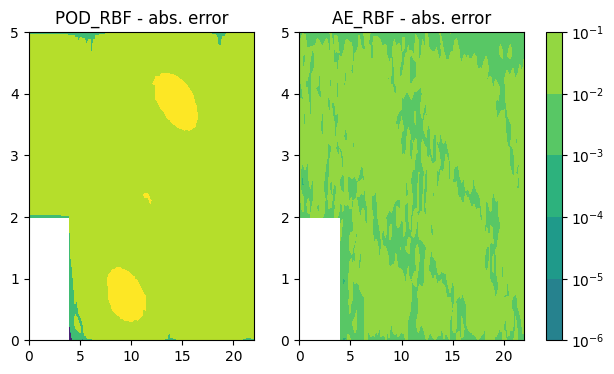

In [9]:
# Visualize the results of each ROM in the multiROM without aggregation on
# some new parameters
ind_min, ind_max = np.argmin(db_test.parameters_matrix), np.argmax(db_test.parameters_matrix)
inds = [ind_min, ind_max]

new_params = [np.min(db_test.parameters_matrix), np.max(db_test.parameters_matrix)]
new_snaps = [db_test.snapshots_matrix[ind_min], db_test.snapshots_matrix[ind_max]]

for j, p in enumerate(new_params):
    print("Test parameter for plotting: ", p)
    fields = []
    roms_pred = [rom.predict([p]).flatten() for rom in roms_dict.values()]
    roms_pred.append(new_snaps[j])
    errs = [np.abs(r - new_snaps[j])+1e-10 for r in roms_pred[:-1]]
    labels = [f'{key}' for key in roms_dict.keys()]
    labels.append("FOM")
    plot_fields(roms_pred, data.triang, labels=labels)
    plot_fields(errs, data.triang, labels=[f"{l} - abs. error" for l in labels], log_cmap=True)

In [10]:
# Fit and save the different multiROMs with aggregation
# KNN
print("Fitting multiROM with KNN aggregation...")
knn = KNeighborsRegressor(n_neighbors=8)
multirom_KNN = MultiROM(roms_dict, plugins=[Aggregation(fit_function=None, predict_function=knn), db_splitter_plugin])
multirom_KNN.fit()

Fitting multiROM with KNN aggregation...
Optimal sigma value in weights:  [0.01011113]


In [11]:
print("Fitting multiROM with ANN aggregation...")
ann = ANN_weights(multirom_noagg, [10, 10, 10],[nn.Softplus(), nn.Softplus(), nn.Softplus(), nn.Softmax(dim=-1)],
                    stop_training=1000, lr=3e-4, frequency_print=100, l2_regularization=1e-4)
multirom_ANN = MultiROM(roms_dict, plugins=[Aggregation(fit_function=ann), db_splitter_plugin])
multirom_ANN.fit()

Fitting multiROM with ANN aggregation...
Using device: 💻 mps
[epoch      1]	1.359506e-02
[epoch    100]	2.392260e-03
[epoch    200]	8.073373e-04
[epoch    300]	3.856815e-04
[epoch    400]	2.416986e-04
[epoch    500]	1.913771e-04
[epoch    600]	1.703329e-04
[epoch    700]	1.598929e-04
[epoch    800]	1.539839e-04
[epoch    900]	1.502719e-04
[epoch   1000]	1.477482e-04


In [12]:
multiroms = {}
multiroms["KNN"] = multirom_KNN
multiroms["ANN"] = multirom_ANN

header = '{:10s}'.format('')
for name in approximation_methods:
    header += ' {:>16s}'.format(name)
print(header)
for redname, redclass in reduction_methods.items():
    row = '{:10s}'.format(redname)
    for approxname, approxclass in approximation_methods.items():
        rom = roms_dict[redname+'_'+approxname]
        row += ' {:16e}'.format(rom.test_error(db_test))
    print(row)
    print('-'*len(row))
for model_name in multiroms:
    row = '{:10s}'.format(model_name)
    multirom_ = multiroms[model_name]
    row += '- MultiROM {:16e}'.format(multirom_.test_error(db_test))
    print(row)

                        RBF
POD            2.864578e-02
---------------------------
AE             7.393730e-04
---------------------------
KNN       - MultiROM     1.709964e-03
ANN       - MultiROM     9.613695e-04


dict_values([<ezyrb.reducedordermodel.MultiReducedOrderModel object at 0x3092fb580>, <ezyrb.reducedordermodel.MultiReducedOrderModel object at 0x31097e790>])
Test parameter for plotting:  2.409551792506808


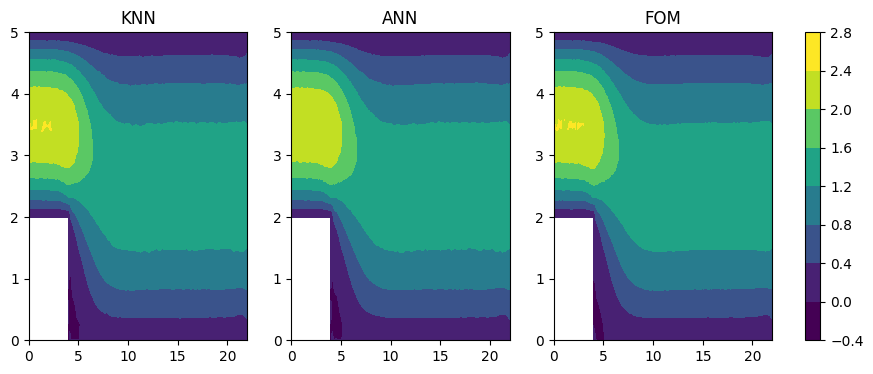

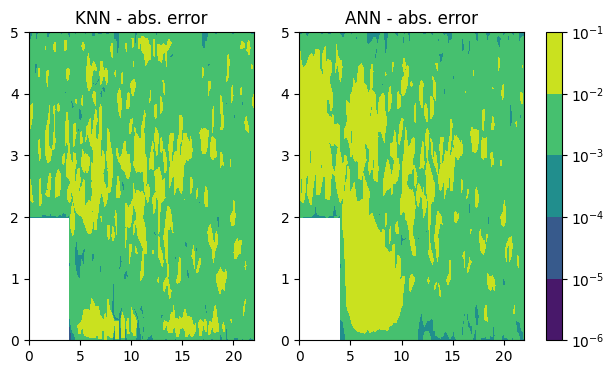

Test parameter for plotting:  78.61875700992475


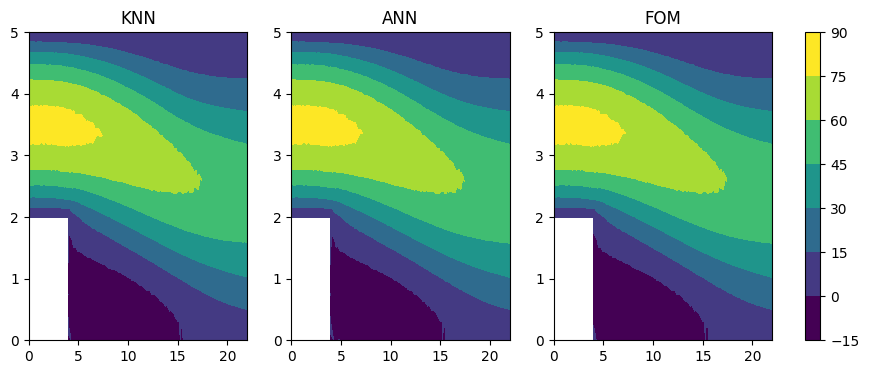

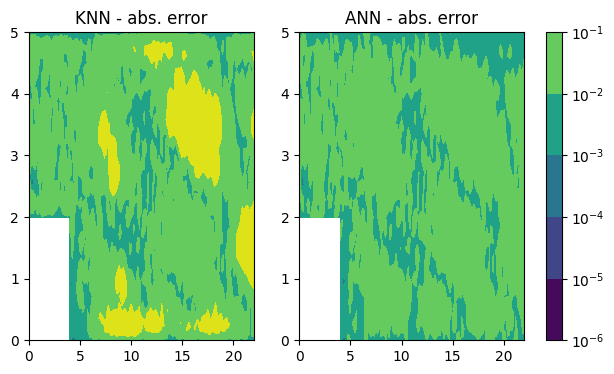

In [14]:
for j, p in enumerate(new_params):
    print("Test parameter for plotting: ", new_params[j])
    fields = []
    roms_pred = []
    for rom in multiroms.values():
        roms_pred.append(rom.predict(np.array([p]).reshape(-1, 1)).flatten())
    roms_pred.append(new_snaps[j].flatten())
    errs = [np.abs(r - new_snaps[j])+1e-10 for r in roms_pred[:-1]]
    labels = list(multiroms.keys())
    labels.append("FOM")
    plot_fields(roms_pred, data.triang, labels=labels)
    plot_fields(errs, data.triang, labels=[f"{l} - abs. error" for l in labels], log_cmap=True)